In [1]:
import numpy as np
import keras 
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import platform

# 한글 폰트 설정
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

In [2]:
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

In [3]:
train_input.shape

(60000, 28, 28)

In [4]:
train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0

In [5]:
train_scaled.shape

(60000, 28, 28, 1)


---
## BASIC

In [6]:
basic_model = keras.Sequential(
    [
        keras.layers.Input(shape=(28, 28, 1)),
        keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
        keras.layers.MaxPooling2D(2),
        keras.layers.Flatten(),
        keras.layers.Dense(100, activation="relu"),
        keras.layers.Dropout(0.4),
        keras.layers.Dense(10, activation="softmax"),
    ]
)

In [7]:
basic_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       627,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 628,630 (2.40 MB)

 Trainable params: 628,630 (2.40 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
basic_model.compile(
    optimizer="adam",
    loss=keras.losses.sparse_categorical_crossentropy,
    metrics=["accuracy"],
    jit_compile=False,
)

In [9]:
checkpoint = keras.callbacks.ModelCheckpoint('best-model.keras', save_best_only=True)
early_stopping = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

In [10]:
history = basic_model.fit(
    train_scaled, train_target,
    callbacks=[checkpoint, early_stopping],
    epochs=20, validation_split=0.2
    )

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8230 - loss: 0.5114 - val_accuracy: 0.8762 - val_loss: 0.3406
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8758 - loss: 0.3502 - val_accuracy: 0.8938 - val_loss: 0.2892
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8921 - loss: 0.3027 - val_accuracy: 0.8972 - val_loss: 0.2869
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9003 - loss: 0.2739 - val_accuracy: 0.9050 - val_loss: 0.2597
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9082 - loss: 0.2507 - val_accuracy: 0.9066 - val_loss: 0.2567
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9138 - loss: 0.2357 - val_accuracy: 0.9077 - val_loss: 0.2574
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9181 - loss: 0.2195 - val_accuracy: 0.9125 - val_loss: 0.2477
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9231 - loss: 0.2049 - 

In [11]:
print("최고 val_accuracy:", max(history.history["val_accuracy"]))
print("최종 val_accuracy:", history.history["val_accuracy"][-1])
print("최종 train_accuracy:", history.history["accuracy"][-1])

최고 val_accuracy: 0.9163333177566528
최종 val_accuracy: 0.9163333177566528
최종 train_accuracy: 0.9359166622161865


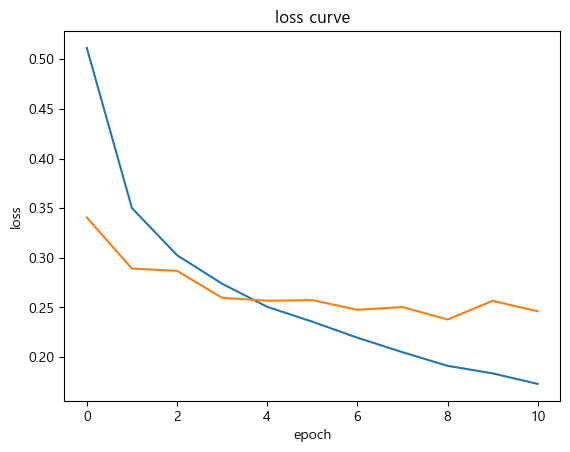

In [12]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("loss curve")
plt.show()

In [13]:
basic_model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9066 - loss: 0.2627


[0.2626643776893616, 0.9065999984741211]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


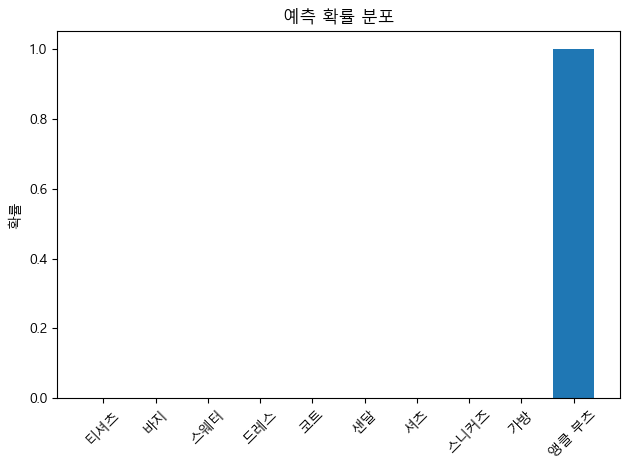

In [14]:
pred = basic_model.predict(test_scaled[0:1])
np.argmax(pred)

classes = ['티셔츠', '바지', '스웨터', '드레스', '코트',
            '샌달', '셔츠', '스니커즈', '가방', '앵클 부츠']

classes[np.argmax(pred)]

plt.bar(range(1, 11), pred[0])
plt.xticks(range(1, 11), classes, rotation=45)
plt.ylabel("확률")
plt.title("예측 확률 분포")
plt.tight_layout()
plt.show()

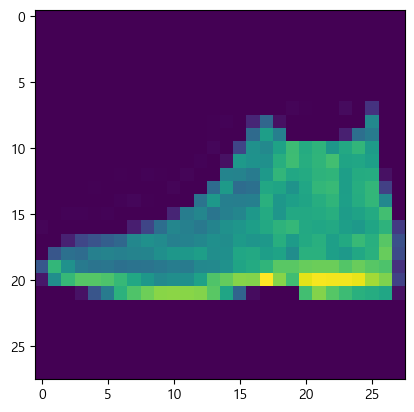

In [15]:
plt.imshow(test_scaled[0])
plt.show()


---
## APPLIED

In [16]:
import time

In [17]:
applied_model = keras.Sequential([
    keras.layers.Input(shape=(28,28,1)),
    # Layer 1
    keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    keras.layers.MaxPool2D(2),
    # Layer 2
    keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
    keras.layers.MaxPool2D(2),
    keras.layers.Flatten(),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(10, activation='softmax')
])


In [18]:
applied_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
applied_model.compile(
    optimizer="adam",
    loss=keras.losses.sparse_categorical_crossentropy,
    metrics=["accuracy"],
    jit_compile=False,
)

In [20]:
checkpoint = keras.callbacks.ModelCheckpoint(
    "applied-best-model.keras", save_best_only=True
)

early_stopping = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

In [21]:
history_applied = applied_model.fit(
    train_scaled,
    train_target,
    epochs=20,
    validation_split=0.2,
    callbacks=[checkpoint, early_stopping],
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8135 - loss: 0.5246 - val_accuracy: 0.8683 - val_loss: 0.3508
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8723 - loss: 0.3530 - val_accuracy: 0.8953 - val_loss: 0.2827
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8917 - loss: 0.3000 - val_accuracy: 0.9033 - val_loss: 0.2598
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9047 - loss: 0.2642 - val_accuracy: 0.9100 - val_loss: 0.2392
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9105 - loss: 0.2432 - val_accuracy: 0.9143 - val_loss: 0.2300
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9206 - loss: 0.2184 - val_accuracy: 0.9183 - val_loss: 0.2247
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9258 - loss: 0.2024 - val_accuracy: 0.9206 - val_loss: 0.2258
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9315 - loss: 0.1848 - 

In [22]:
print("최고 val_accuracy:", max(history_applied.history["val_accuracy"]))

최고 val_accuracy: 0.9227499961853027


In [23]:
applied_model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9173 - loss: 0.2448


[0.24481721222400665, 0.9172999858856201]

In [24]:
print("APPLIED 최고 val_accuracy:", max(history_applied.history["val_accuracy"]))
print("APPLIED 최종 val_accuracy:", history_applied.history["val_accuracy"][-1])
print("APPLIED 최종 train_accuracy:", history_applied.history["accuracy"][-1])

APPLIED 최고 val_accuracy: 0.9227499961853027
APPLIED 최종 val_accuracy: 0.9203333258628845
APPLIED 최종 train_accuracy: 0.9401666522026062


In [25]:
import pandas as pd

result_df = pd.DataFrame(
    {
        "모델": ["BASIC", "APPLIED"],
        "구조": ["Conv2D(32)", "Conv2D(32) → Conv2D(64)"],
        "파라미터 수": [basic_model.count_params(), applied_model.count_params()],
        "최고 val_accuracy": [
            max(history.history["val_accuracy"]),
            max(history_applied.history["val_accuracy"]),
        ],
    }
)

result_df

,모델,구조,파라미터 수,최고 val_accuracy
0,BASIC,Conv2D(32),628630,0.916333
1,APPLIED,Conv2D(32) → Conv2D(64),333526,0.922750
